<a href="https://colab.research.google.com/github/Roohikhan12/dataviz-exercises-Roohi-Khan/blob/main/lecture03_exercise_RK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('/content/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


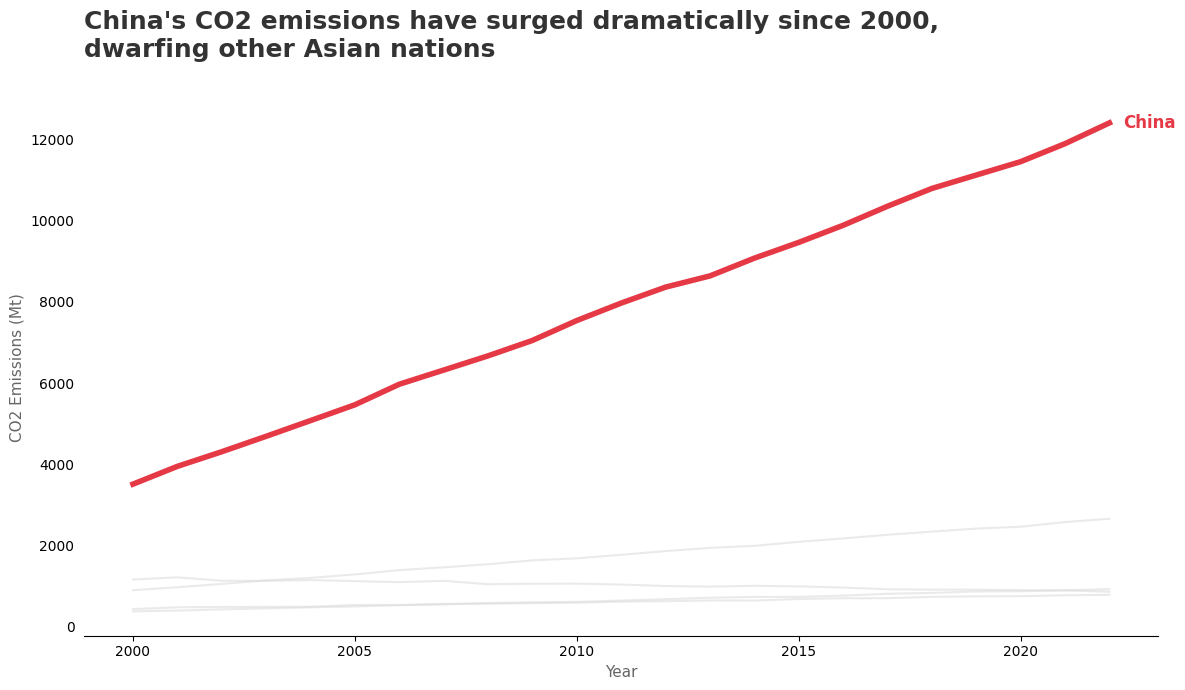

In [9]:
import matplotlib.pyplot as plt

# Task 1 — Multi-series line with highlight


# Filter for Asia
asia_df = df[df['Region'] == 'Asia']
countries = asia_df['Country'].unique()
highlight_country = 'China'
highlight_color = '#E63946' # Professional Red

plt.figure(figsize=(12, 7))
ax = plt.gca()

for country in countries:
    country_data = asia_df[asia_df['Country'] == country]

    if country == highlight_country:
        color = highlight_color
        linewidth = 4
        alpha = 1.0
        zorder = 10
    else:
        color = '#DDDDDD'
        linewidth = 1.5
        alpha = 0.6
        zorder = 1

    ax.plot(country_data['Year'], country_data['CO2_Mt'],
            color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)

    # Direct labeling at the end of the line
    if country == highlight_country:
        last_row = country_data[country_data['Year'] == 2022]
        ax.text(2022.3, last_row['CO2_Mt'].values[0], highlight_country,
                color=color, fontweight='bold', va='center', fontsize=12)

# Clutter Removal
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_ticks_position('none')
ax.grid(False)

# Insight title stating the finding
plt.title("China's CO2 emissions have surged dramatically since 2000,\ndwarfing other Asian nations",
          loc='left', fontsize=18, pad=30, fontweight='bold', color='#333333')

plt.xlabel('Year', fontsize=11, color='#666666')
plt.ylabel('CO2 Emissions (Mt)', fontsize=11, color='#666666')
plt.tight_layout()
plt.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


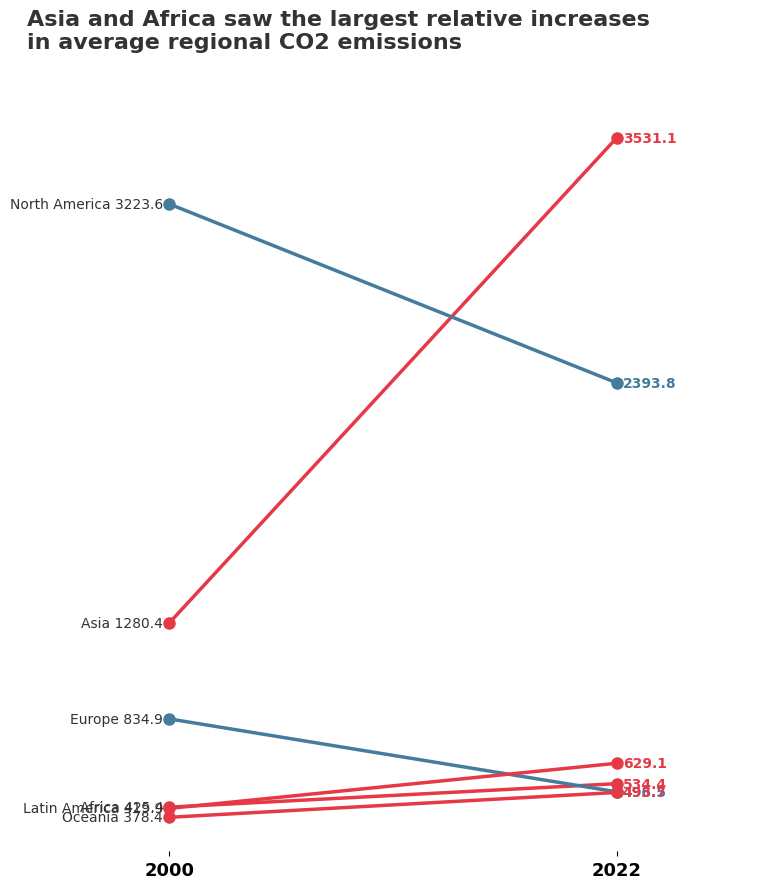

In [10]:
import matplotlib.pyplot as plt

# Task 2 — Slopegraph: regional averages
# Aggregate regional averages and filter for years
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

plt.figure(figsize=(8, 9))
ax = plt.gca()

regions = slope_df['Region'].unique()

for region in regions:
    region_data = slope_df[slope_df['Region'] == region].sort_values('Year')
    v0 = region_data[region_data['Year'] == 2000]['CO2_Mt'].values[0]
    v1 = region_data[region_data['Year'] == 2022]['CO2_Mt'].values[0]

    # Color: Red for increase, Blue for decrease
    color = '#E63946' if v1 > v0 else '#457B9D'

    # Plot the slope line
    ax.plot([2000, 2022], [v0, v1], color=color, marker='o', markersize=8, linewidth=2.5)

    # Label 2000 side (left)
    ax.text(1999.7, v0, f"{region} {v0:.1f}", ha='right', va='center', fontsize=10, color='#333333')

    # Label 2022 side (right)
    ax.text(2022.3, v1, f"{v1:.1f}", ha='left', va='center', fontsize=10, fontweight='bold', color=color)

# Slopegraph formatting
ax.set_xlim(1993, 2029)
ax.set_xticks([2000, 2022])
ax.set_xticklabels(['2000', '2022'], fontsize=13, fontweight='bold')
ax.set_yticks([]) # Redundant labels removed
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Insight title
plt.title("Asia and Africa saw the largest relative increases\nin average regional CO2 emissions",
          loc='left', fontsize=16, pad=40, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()